In [22]:
# setting up
import os
import subprocess
from more_itertools import strip
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt
import pandas as pd
import re

# shortcuts
home = '~/research/'
phylobc_script = home + 'nielsen_lab/phylogenetic-base-calling/call_bases_from_pileup.py'

# Was original reference db abundant in N's?

<AxesSubplot:ylabel='Count'>

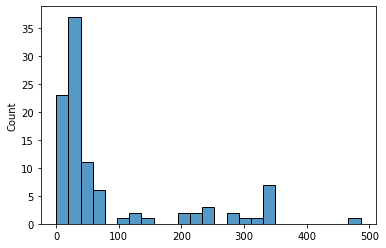

In [2]:
# tally up N's per sample using initial fasta
og_fasta_path = "step1_msa/SARS-CoV-2_100genomes.fasta"
with open(og_fasta_path) as file:
    unaligned_seqs = [line.rstrip() for line in file]
names = [unaligned_seqs[i] for i in range(len(unaligned_seqs)) if i%2 == 0] # even indexes are names
seqs = [unaligned_seqs[i] for i in range(len(unaligned_seqs)) if i%2 != 0] # uneven indexes are sequences

n_counts = [sum([1 for b in list(seq) if b.lower()=='n']) for seq in seqs]
sea.histplot(n_counts, cumulative=False)

# MSA using only sequences without excess N's

<AxesSubplot:ylabel='Count'>

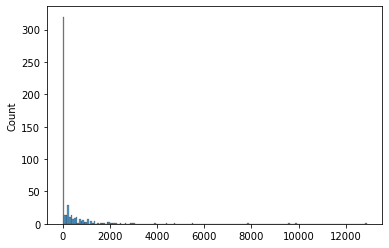

In [3]:
# tally up N's per sample using initial fasta
og_fasta_path = "step1_msa/SARS-CoV-2_500genomes.fasta"
with open(og_fasta_path) as file:
    unaligned_seqs = [line.rstrip() for line in file]
names = [unaligned_seqs[i] for i in range(len(unaligned_seqs)) if i%2 == 0] # even indexes are names
seqs = [unaligned_seqs[i] for i in range(len(unaligned_seqs)) if i%2 != 0] # uneven indexes are sequences

n_counts = [sum([1 for b in list(seq) if b.lower()=='n']) for seq in seqs]
sea.histplot(n_counts, cumulative=False)

In [4]:
# remove too many N's and create new fasta
indexes_to_keep = [i for i,n in enumerate(n_counts) if n<10]
with open('/Users/marniella/research/nielsen_lab/phylogenetic-base-calling/step1_msa/SARS-CoV-2_282genomes.fasta', 'a') as f:
    for i in indexes_to_keep:
        f.write( names[i] + '\n' + seqs[i] + '\n')
f.close()

In [5]:
len(indexes_to_keep)

282

# Finding dups in the multiple sequence alignment (MSA)

In [6]:
# old 100-seq MSA is at:
# /Users/marniella/research/rotations/r3_nielsen/2022fall/alignment101_mafft2/alignment101.fasta

## > 500-seq MSA -> excess N's out -> 284-seq MSA

In [7]:
msa_path = "/Users/marniella/research/nielsen_lab/phylogenetic-base-calling/step1_msa/msa284.fasta"
with open(msa_path) as file:
    msa_seqs = [line.rstrip() for line in file]
names = [msa_seqs[i] for i in range(len(msa_seqs)) if i%2 == 0] # even indexes are names
seqs = [msa_seqs[i] for i in range(len(msa_seqs)) if i%2 != 0] # uneven indexes are sequences

### Hashing the cropped sequences: too many unique

In [8]:
# create a dictionary of the sequences but cropping out the heads/tails
msa_dict_crop = {seq[1000:-1000]:names for seq in seqs}
print(len(msa_dict_crop))

282


### Hashing sequences w/o N's or gaps: too few unique

In [9]:
## try different approach
# get all the sites that have an N or gap
keep_sites = [True]*len(seqs[0])
for s in seqs:
    for i in range(len(keep_sites)):
        if s[i].lower() == 'n':
            keep_sites[i] = False

# now take them out of all the sequences
no_n_seqs = [''.join([og_seq[keep] for keep in range(len(keep_sites)) if keep==True]) for og_seq in seqs]

# now create a dictionary of the N's-removed sequences
msa_dict_no_n = {no_n_seqs[i]:names[i] for i in range(len(names))}
print(len(msa_dict_no_n))

3


### Pairwise comparison

In [10]:
def are_bases_distinct(a,b):
    # N's don't make bases distinct
    if (a.lower() == 'n') or (b.lower() == 'n'):
        return False
    else:
        return not (a==b)

def might_be_same(s1, s2):
    # return the sequence with most bases
    return 0

# def compare_seqs(seq1, seq2):
#     # for

# After MSA, how are the priors (from pruned vs. not pruned trees) different?

In [11]:
pruned_prior_df = pd.read_csv('ou_not_pruned/OU_PP_indexed.txt', sep = '\t', index_col='position')
not_pruned_prior_df = pd.read_csv('ou_pruned/OU_PP_indexed.txt', sep = '\t', index_col='position')

In [17]:
pruned_max_base = [base[3:] for base in pruned_prior_df.idxmax(axis=1)]
not_pruned_max_base = [base[3:] for base in not_pruned_prior_df.idxmax(axis=1)]

# are the maximum probability bases any different?
diffs = [(pos,pb,npb) for pos,(pb,npb) in enumerate(zip(pruned_max_base,not_pruned_max_base)) if pb!=npb]
print(diffs)

for pos,(pb,npb) in enumerate(zip(pruned_max_base,not_pruned_max_base)):
    if pb!=npb:
        print(pos, (pb,npb))

[]


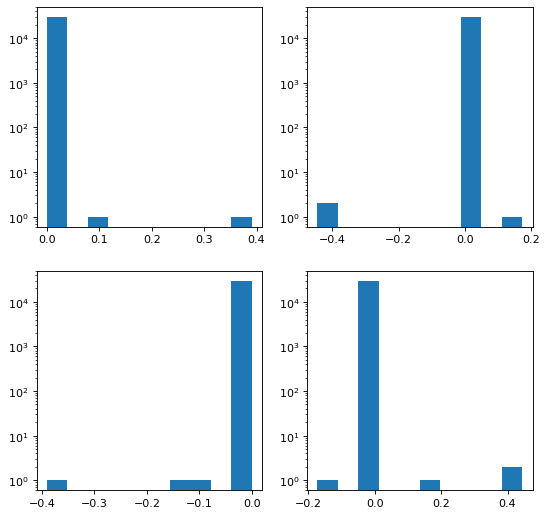

In [30]:
fig = plt.figure(figsize=(8, 8), dpi=80)
plt.subplot(2, 2, 1)
plt.hist(pruned_prior_df['PP_A'] - not_pruned_prior_df['PP_A'], log=True)
plt.subplot(2, 2, 2)
plt.hist(pruned_prior_df['PP_C'] - not_pruned_prior_df['PP_C'], log=True)
plt.subplot(2, 2, 3)
plt.hist(pruned_prior_df['PP_G'] - not_pruned_prior_df['PP_G'], log=True)
plt.subplot(2, 2, 4)
plt.hist(pruned_prior_df['PP_T'] - not_pruned_prior_df['PP_T'], log=True)
plt.show()

In [31]:
([diff if (diff >= 0.3) for diff in (pruned_prior_df['PP_A'] - not_pruned_prior_df['PP_A'])])

1